In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix,roc_curve, auc
from transformers import AutoTokenizer
from transformers import TFAutoModelForSequenceClassification


In [ ]:
print(tf.__version__)

2.18.0


In [ ]:
train = pd.read_parquet("train.parquet")
test = pd.read_parquet("test.parquet")

In [ ]:
X_train, y_train = train["text"].values, train["label"].values
X_test, y_test = test["text"].values, test["label"].values

In [ ]:
model_name = "dccuchile/bert-base-spanish-wwm-uncased"
num_classes = 2
tokenizer = AutoTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/310 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/650 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/248k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/486k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

In [ ]:
max_length= 64
train_encodings = tokenizer(X_train.tolist(), truncation=True, padding=True,max_length=max_length)
test_encodings = tokenizer(X_test.tolist(), truncation=True, padding=True, max_length = max_length)

In [ ]:
train_dataset = tf.data.Dataset.from_tensor_slices((
    dict(train_encodings),
    y_train
))

test_dataset = tf.data.Dataset.from_tensor_slices((
    dict(test_encodings),
    y_test
))

In [ ]:
model = TFAutoModelForSequenceClassification.from_pretrained(model_name, num_labels = num_classes)

tf_model.h5:   0%|          | 0.00/537M [00:00<?, ?B/s]

All model checkpoint layers were used when initializing TFBertForSequenceClassification.

Some layers of TFBertForSequenceClassification were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-uncased and are newly initialized: ['classifier', 'bert/pooler/dense/kernel:0', 'bert/pooler/dense/bias:0']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
opt = tf.keras.optimizers.Adam(learning_rate = 1e-5)
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = True)
model.compile(optimizer = opt, loss = loss, metrics = ["accuracy"])

In [ ]:
history = model.fit(train_dataset.batch(64),
           epochs = 5,
           validation_data = test_dataset.batch(64))

Epoch 1/5
1011/1011 [==============================] - 890s 837ms/step - loss: 0.4325 - accuracy: 0.7940 - val_loss: 0.3669 - val_accuracy: 0.8418
Epoch 2/5
1011/1011 [==============================] - 843s 833ms/step - loss: 0.2568 - accuracy: 0.8954 - val_loss: 0.2829 - val_accuracy: 0.8923
Epoch 3/5
1011/1011 [==============================] - 842s 833ms/step - loss: 0.1581 - accuracy: 0.9394 - val_loss: 0.2480 - val_accuracy: 0.9125
Epoch 4/5
1011/1011 [==============================] - 844s 834ms/step - loss: 0.1048 - accuracy: 0.9618 - val_loss: 0.1801 - val_accuracy: 0.9403
Epoch 5/5
1011/1011 [==============================] - 842s 833ms/step - loss: 0.0746 - accuracy: 0.9726 - val_loss: 0.1859 - val_accuracy: 0.9442


In [ ]:
y_pred = tf.argmax(model.predict(test_dataset.batch(64)).logits, axis=1)

253/253 [==============================] - 72s 274ms/step


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.92      0.94      8149
           1       0.92      0.97      0.95      8018

    accuracy                           0.94     16167
   macro avg       0.95      0.94      0.94     16167
weighted avg       0.95      0.94      0.94     16167



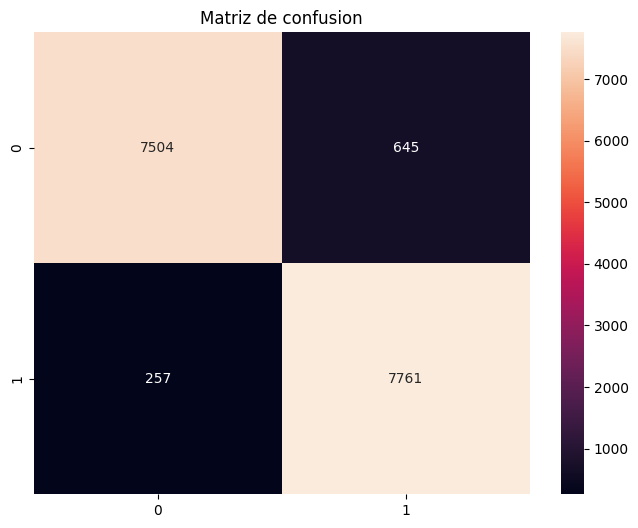

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
plt.title("Matriz de confusion")
sns.heatmap(cm, annot=True, fmt = "d")
plt.show()

In [ ]:
logits = model.predict(test_dataset.batch(64)).logits
probabilities = tf.nn.softmax(logits).numpy()
y_scores = probabilities[:, 1]

253/253 [==============================] - 69s 273ms/step


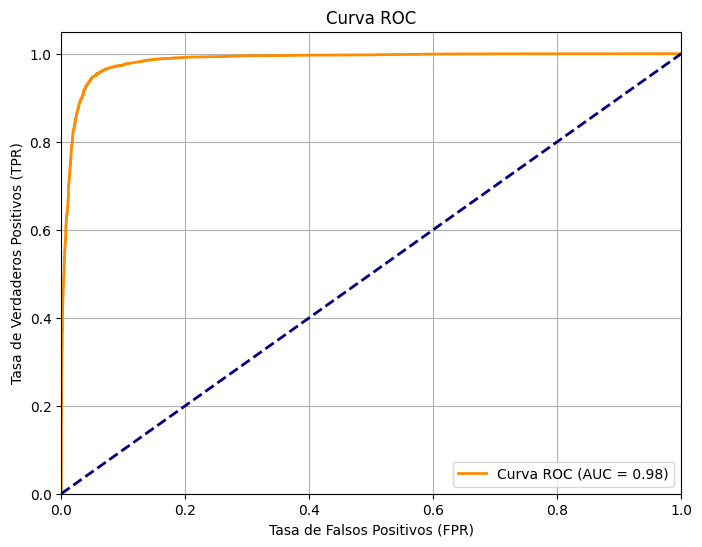

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Línea diagonal
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()
